In [14]:
import sys
from pathlib import Path
sys.path.append(f"{Path().absolute().parent}")

In [15]:
from __future__ import annotations

from MRO_library import *
import plots
from radp.digital_twin.utils.gis_tools import GISTools

### Data Preprocessing

In [16]:
ue_data = pd.read_csv('data/sim_data/UE_data_20UE_100ticks.csv')
ue_data

,mock_ue_id,longitude,latitude,tick
0,0,-22.625309,59.806764,0
1,1,119.764151,54.857584,0
2,2,72.095437,-20.253892,0
3,3,-67.548009,-38.100941,0
4,4,59.867089,-83.103930,0
...,...,...,...,...
1995,15,45.564260,42.609846,99
1996,16,132.457280,17.241235,99
1997,17,-101.217659,72.295988,99
1998,18,-16.480045,-26.656397,99


In [17]:
topology = pd.read_csv('data/sim_data/topology.csv')

topology.loc[topology['cell_id'] == 'cell_1', 'cell_lat'] = -90
topology.loc[topology['cell_id'] == 'cell_2', 'cell_lat'] = 0
topology.loc[topology['cell_id'] == 'cell_3', 'cell_lat'] = 90

topology.loc[topology['cell_id'] == 'cell_1', 'cell_lon'] = -180
topology.loc[topology['cell_id'] == 'cell_2', 'cell_lon'] = 0
topology.loc[topology['cell_id'] == 'cell_3', 'cell_lon'] = 180

topology.loc[topology['cell_id'] == 'cell_1', 'cell_carrier_freq_mhz'] = 1500
topology.loc[topology['cell_id'] == 'cell_2', 'cell_carrier_freq_mhz'] = 1500
topology.loc[topology['cell_id'] == 'cell_3', 'cell_carrier_freq_mhz'] = 1800

topology

,cell_lat,cell_lon,cell_id,cell_az_deg,cell_carrier_freq_mhz
0,-90.0,-180.0,cell_1,0,1500
1,0.0,0.0,cell_2,120,1500
2,90.0,180.0,cell_3,240,1800


In [18]:
data = concatenate_ue_to_topology(ue_data, topology)
data = connect_ue_to_all_cells(data, topology)

In [19]:
# Calculating distance and received power
data['distance_km'] = data.apply(lambda row: GISTools.get_log_distance(
    row['latitude'], row['longitude'], row['cell_lat'], row['cell_lon']), axis=1)
data['cell_rxpower_dbm'] = data.apply(lambda row: calculate_received_power(
    row['distance_km'], row['cell_carrier_freq_mhz']), axis=1)
# Rename Mock UE ID to UE ID for consistency
data = data.rename(columns={'mock_ue_id': 'ue_id'})
data['ue_id'] = data["ue_id"].astype(int)
topology["cell_id"] = topology["cell_id"].str.replace('cell_', '').astype(int)
data['cell_id'] = data['cell_id'].str.extract('(\d+)').astype(int)
data = data.rename(columns={'latitude': 'loc_y', 'longitude': 'loc_x'})
data['relative_bearing'] = data.apply(lambda row: GISTools.get_relative_bearing(
    row['cell_az_deg'], row['cell_lat'], row['cell_lon'],row['loc_y'],row['loc_y']), axis=1)
# data = data.rename(columns={'cell_rxpower_dbm': 'rsrp_dbm'})
data = add_sinr_column(data)

### Perform Attachment w/ Hyst & TTT

In [20]:
data

,ue_id,loc_x,loc_y,tick,cell_lat,cell_lon,cell_id,cell_az_deg,cell_carrier_freq_mhz,distance_km,cell_rxpower_dbm,relative_bearing,sinr_db
0,0,-22.625309,59.806764,0.0,-90.0,-180.0,1,0,1500,16.629500,-97.389409,239.806764,-19.803317
1,0,-22.625309,59.806764,0.0,0.0,0.0,2,120,1500,15.752768,-96.918963,266.698642,-19.803317
2,0,-22.625309,59.806764,0.0,90.0,180.0,3,240,1800,15.027772,-98.093342,60.193236,-19.803317
3,1,119.764151,54.857584,0.0,-90.0,-180.0,1,0,1500,16.595905,-97.371844,234.857584,-19.646533
4,1,119.764151,54.857584,0.0,0.0,0.0,2,120,1500,16.289273,-97.209859,269.925194,-19.646533
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,18,-16.480045,-26.656397,99.0,0.0,0.0,2,120,1500,15.054748,-96.525295,101.787576,-14.360112
5996,18,-16.480045,-26.656397,99.0,90.0,180.0,3,240,1800,16.379387,-98.841403,146.656397,-14.360112
5997,19,34.222834,63.970820,99.0,-90.0,-180.0,1,0,1500,16.656917,-97.403718,243.970820,-17.263002
5998,19,34.222834,63.970820,99.0,0.0,0.0,2,120,1500,15.850264,-96.972555,263.693251,-17.263002


#### HyperParameters

In [21]:
hyst = 1.25
ttt = 5
rlf_threshold = -19.9

In [22]:
attached_df = perform_attachment_hyst_ttt(data, hyst, ttt, rlf_threshold)

In [23]:
attached_df

,ue_id,loc_x,loc_y,tick,cell_lat,cell_lon,cell_id,cell_az_deg,cell_carrier_freq_mhz,distance_km,cell_rxpower_dbm,relative_bearing,sinr_db
1,0.0,-22.625309,59.806764,0.0,0.0,0.0,2,120.0,1500.0,15.752768,-96.918963,266.698642,-19.803317
4,1.0,119.764151,54.857584,0.0,0.0,0.0,2,120.0,1500.0,16.289273,-97.209859,269.925194,-19.646533
6,2.0,72.095437,-20.253892,0.0,-90.0,-180.0,RLF,0.0,1500.0,15.865016,-inf,159.746108,-inf
9,3.0,-67.548009,-38.100941,0.0,-90.0,-180.0,RLF,0.0,1500.0,15.569455,-inf,141.899059,-inf
12,4.0,59.867089,-83.103930,0.0,-90.0,-180.0,1,0.0,1500.0,13.551107,-95.611321,96.896070,-19.533091
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15,15.0,45.564260,42.609846,99.0,0.0,0.0,2.0,120.0,1500.0,15.697432,-96.888398,276.352353,-17.428152
16,16.0,132.457280,17.241235,99.0,0.0,0.0,2.0,120.0,1500.0,16.488794,-97.315603,283.683361,-16.714365
17,17.0,-101.217659,72.295988,99.0,-90.0,-180.0,1.0,0.0,1500.0,16.709576,-97.431134,252.295988,-17.194907
18,18.0,-16.480045,-26.656397,99.0,0.0,0.0,2.0,120.0,1500.0,15.054748,-96.525295,101.787576,-14.360112


In [ ]:
print(f"MRO Score: {calculate_mro_metric(attached_df)}")

MRO Score: -300.05


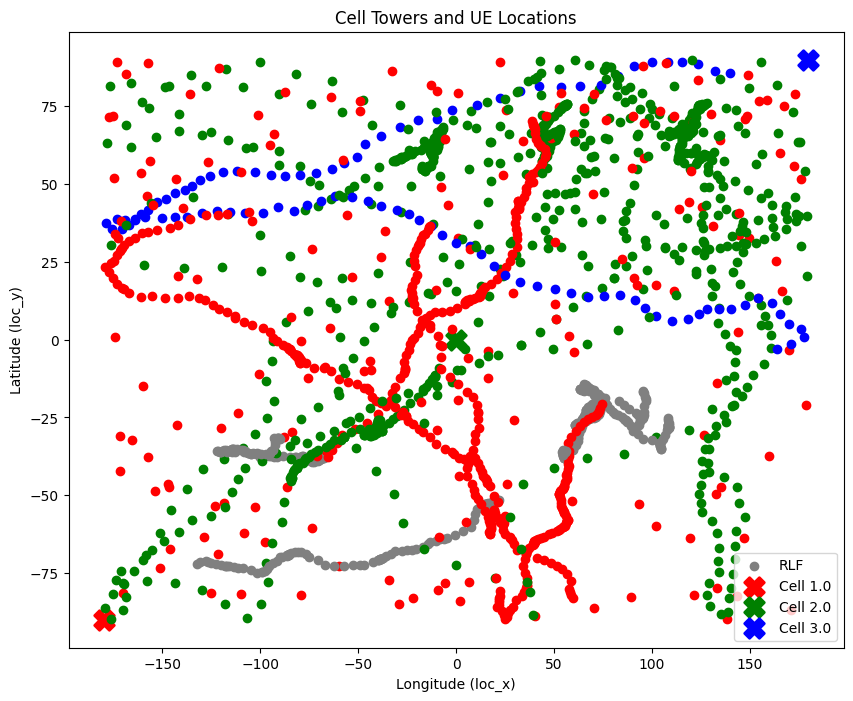

In [25]:
plots.plot_scatter2(attached_df, topology)

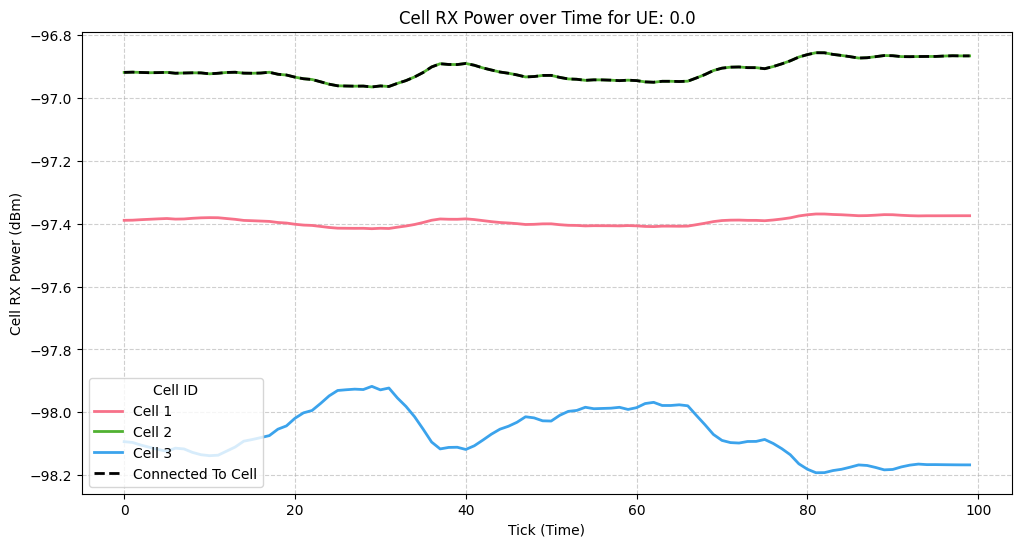

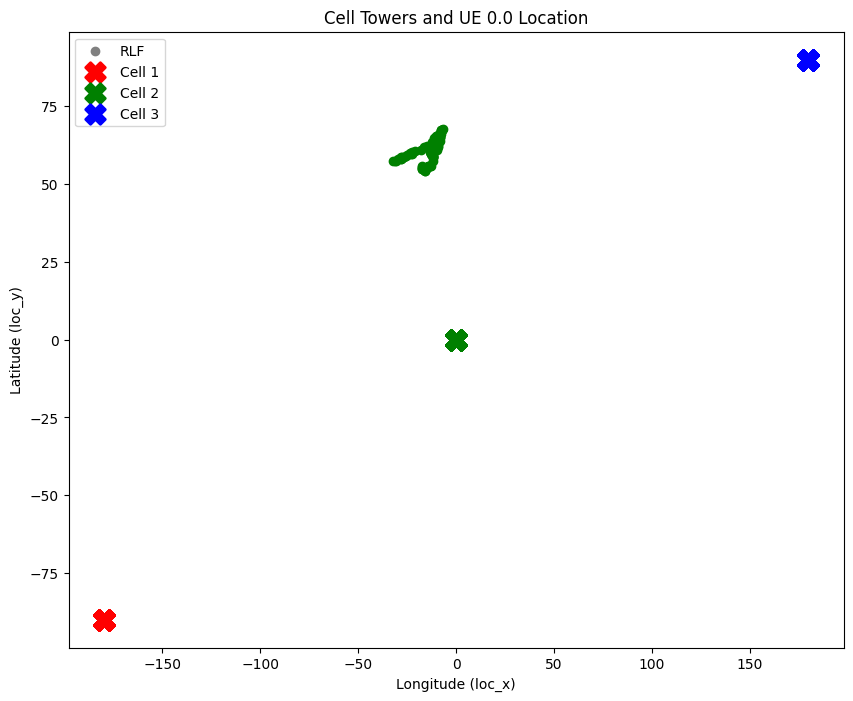

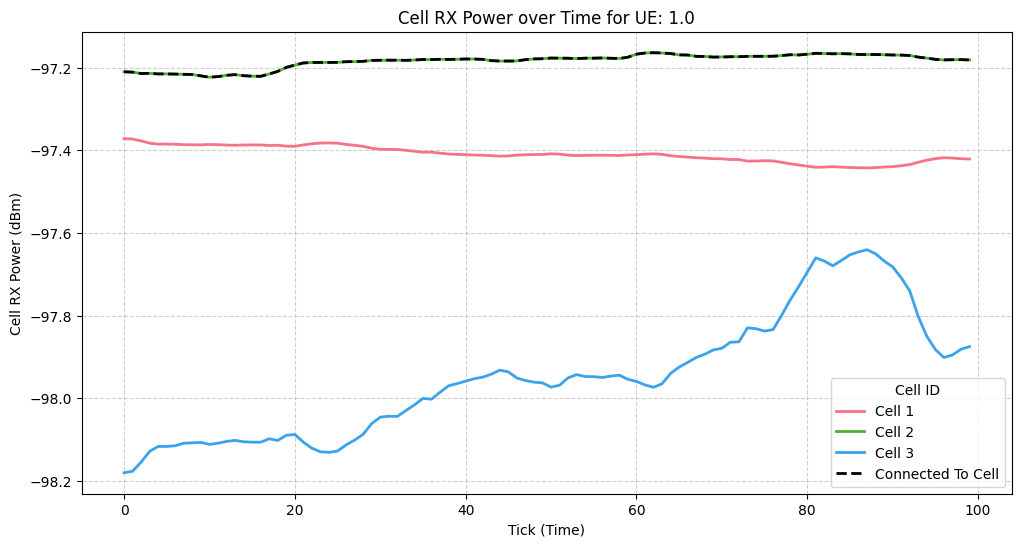

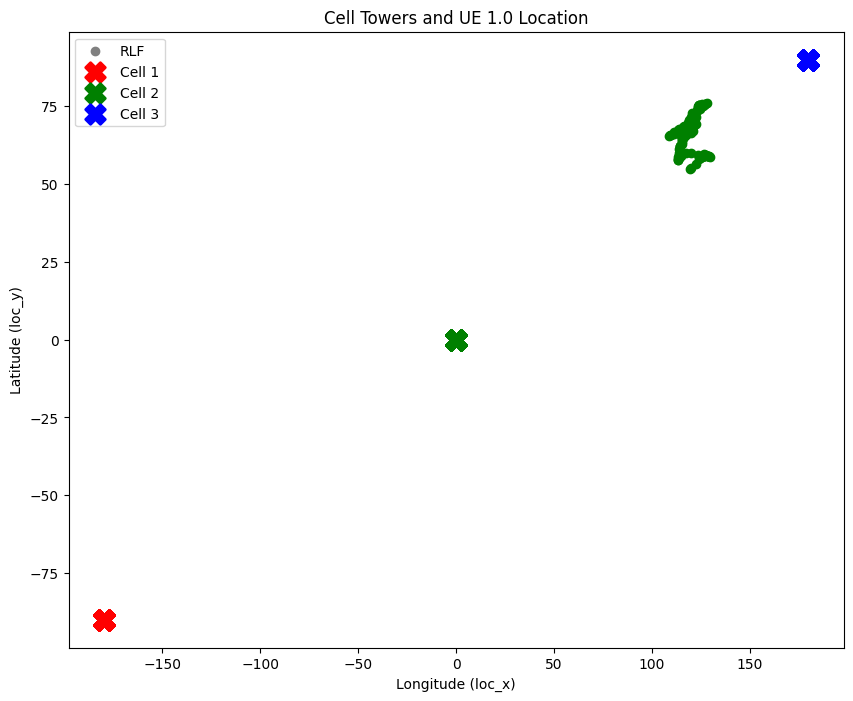

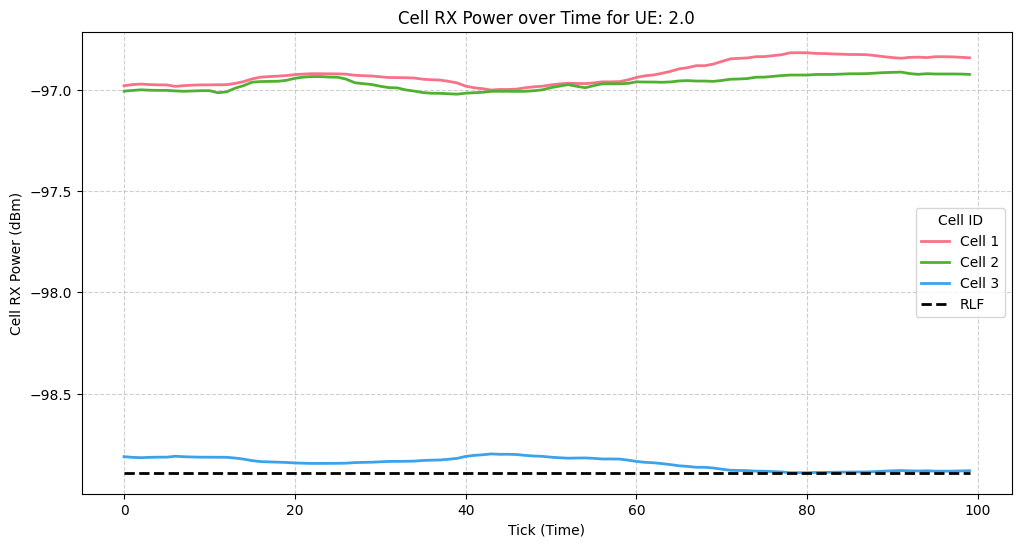

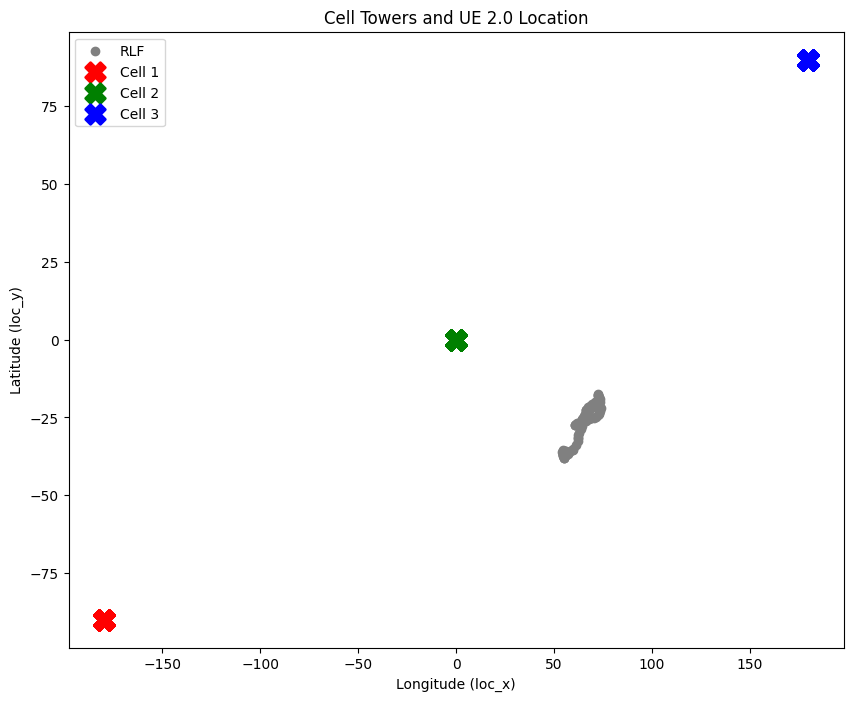

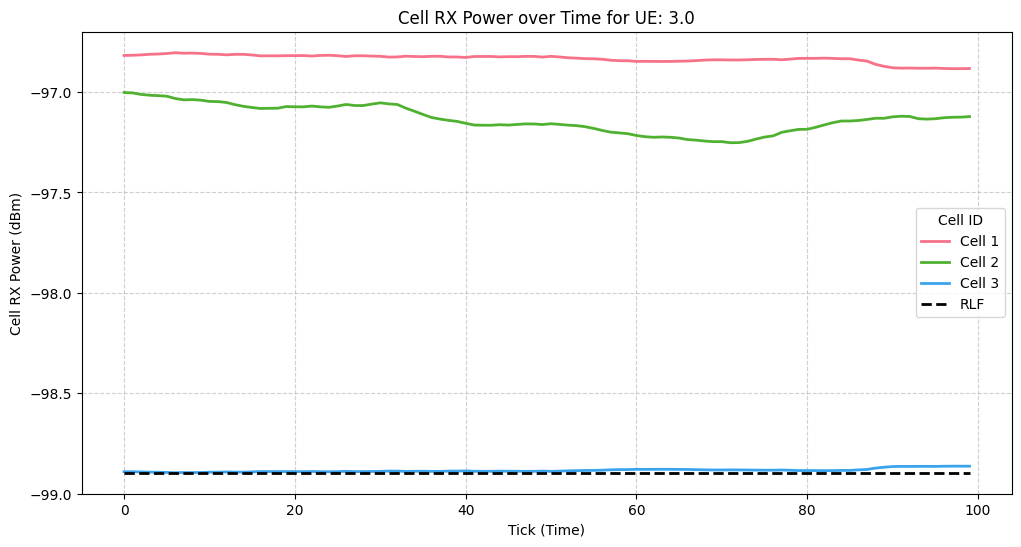

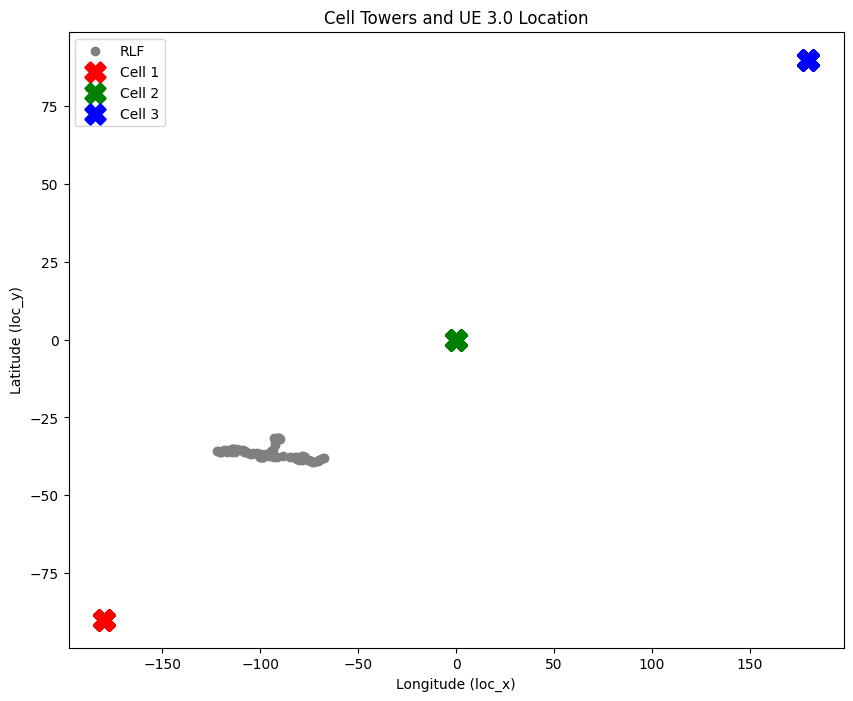

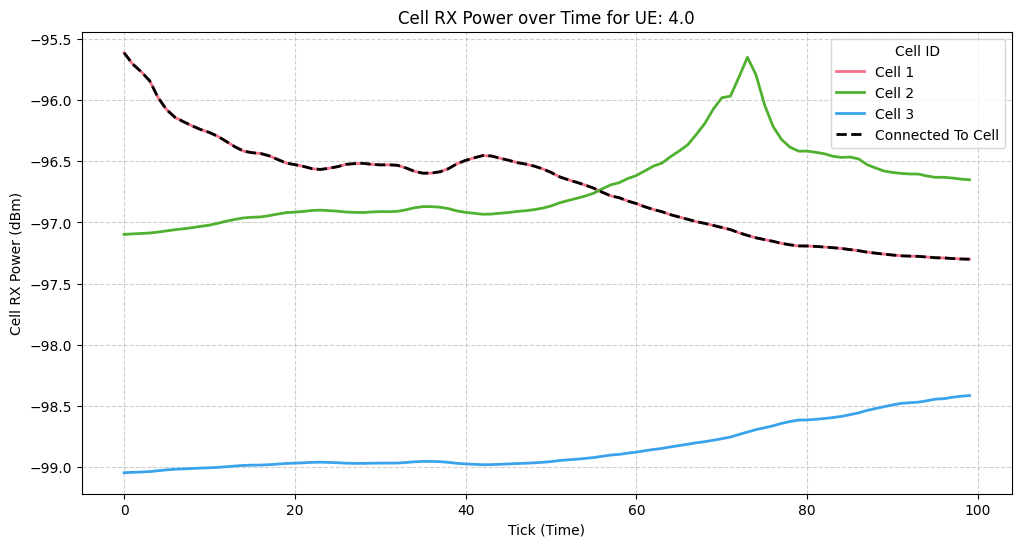

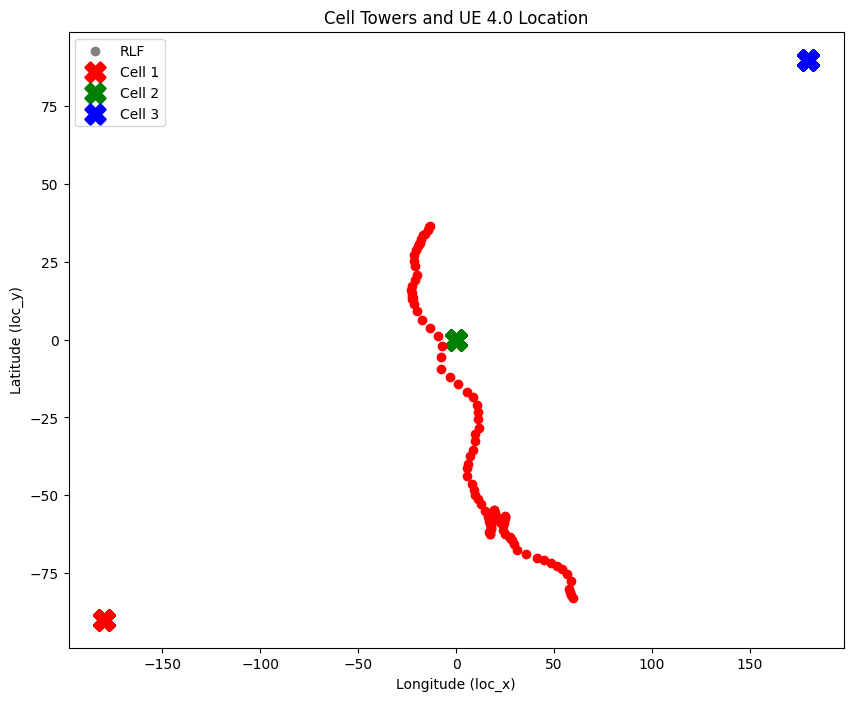

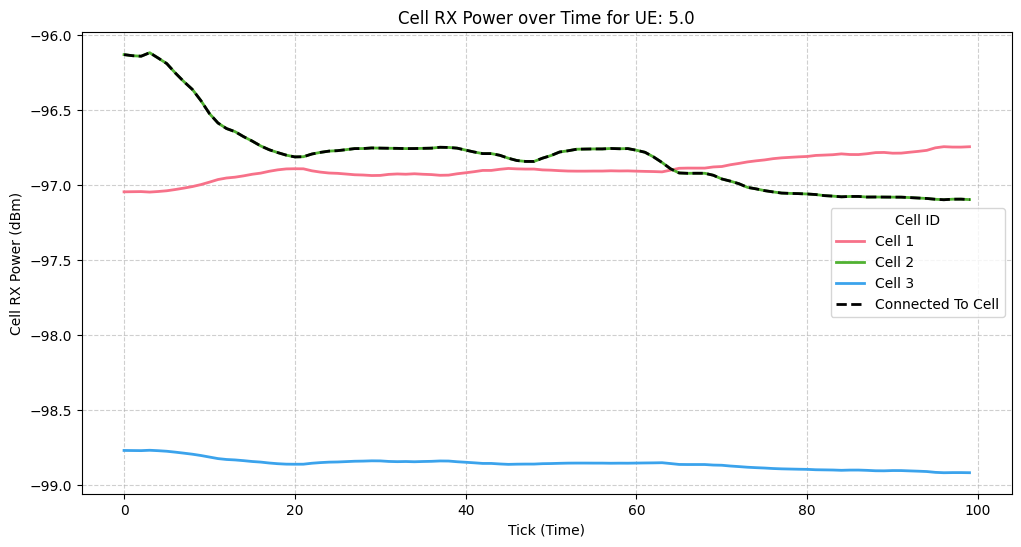

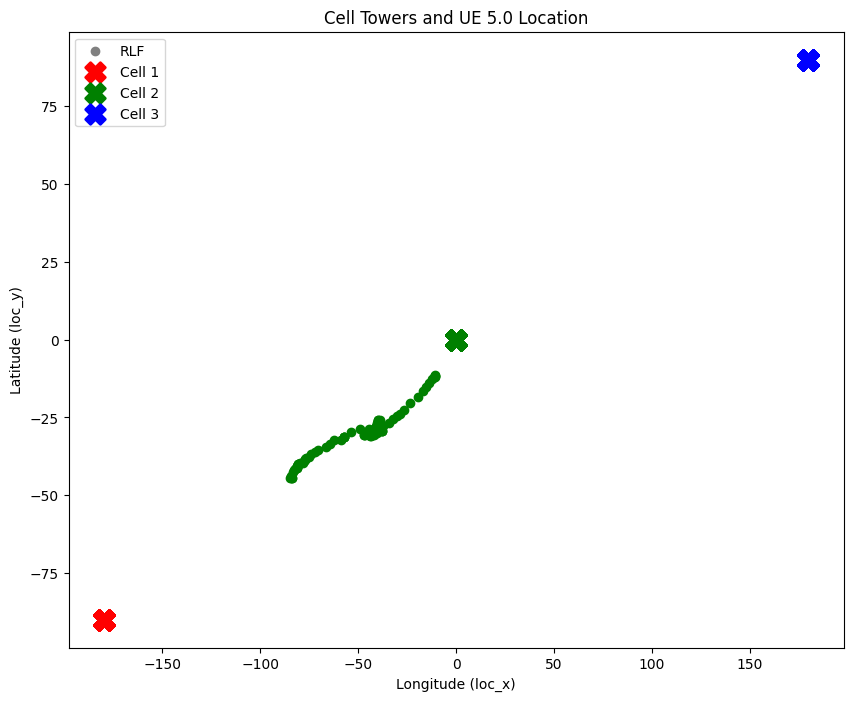

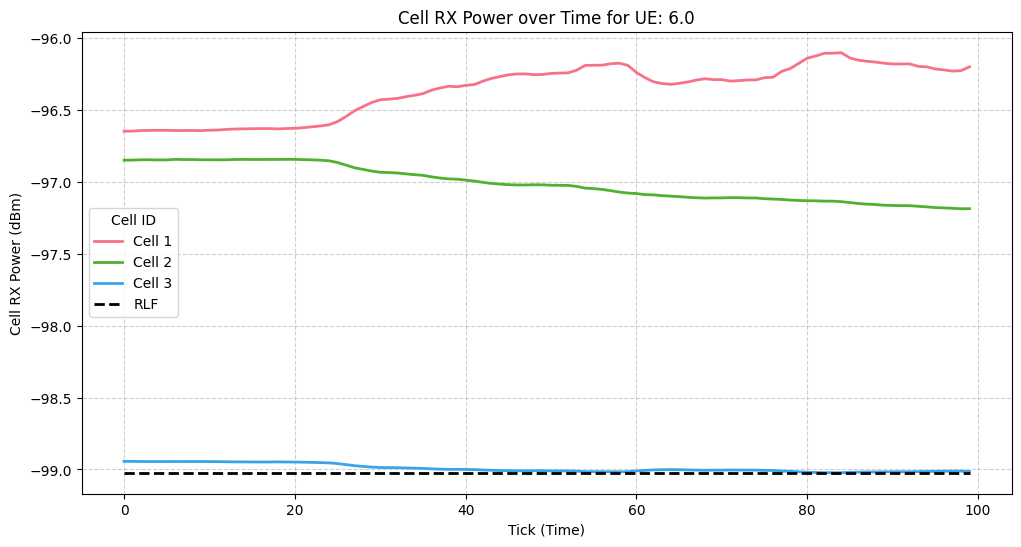

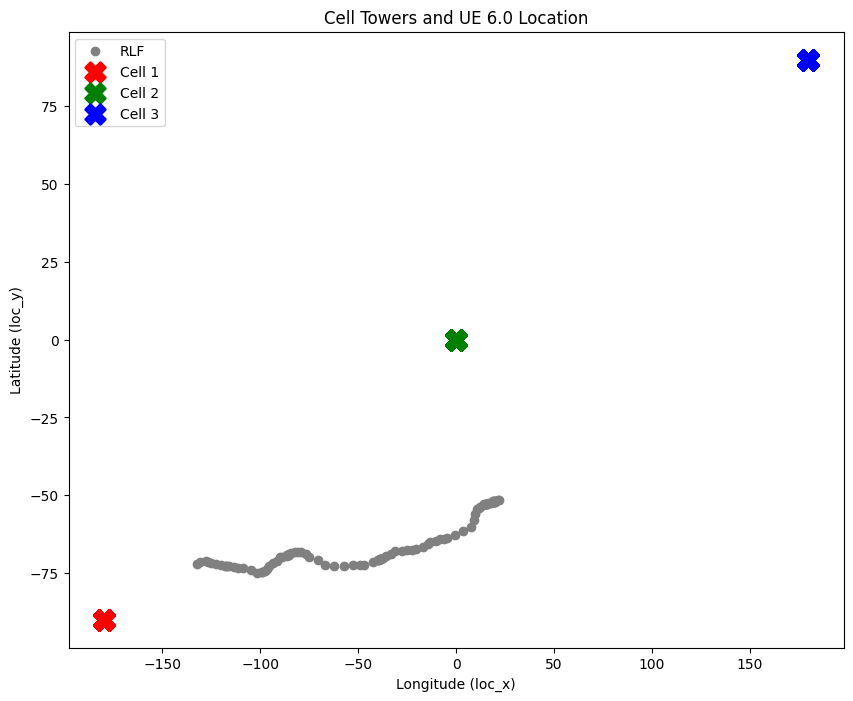

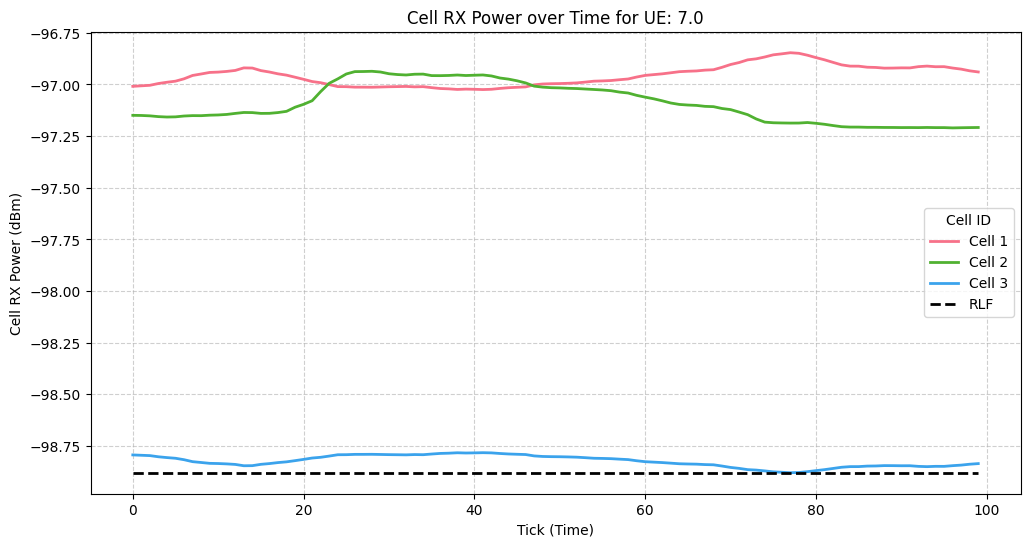

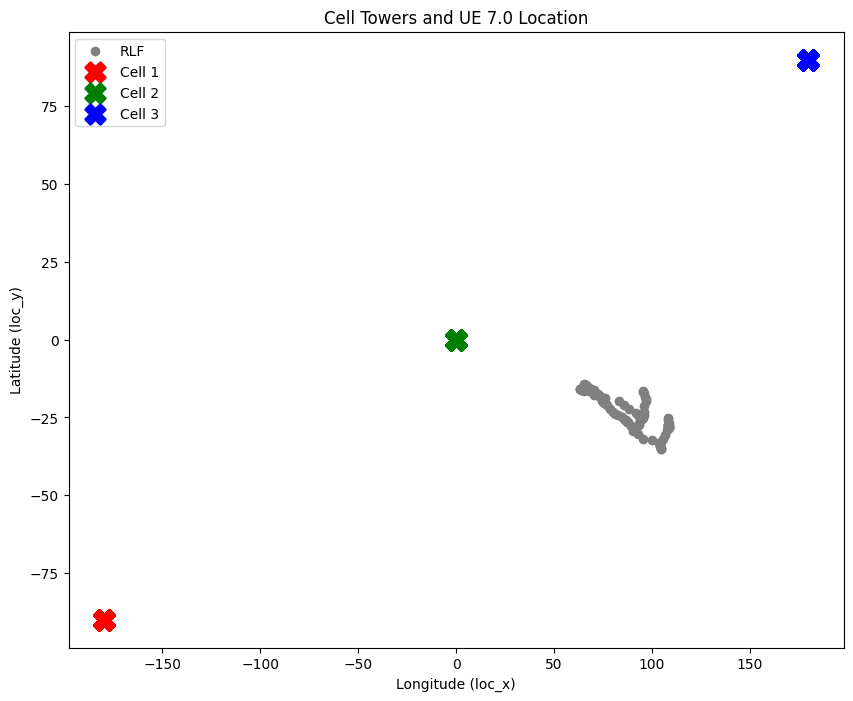

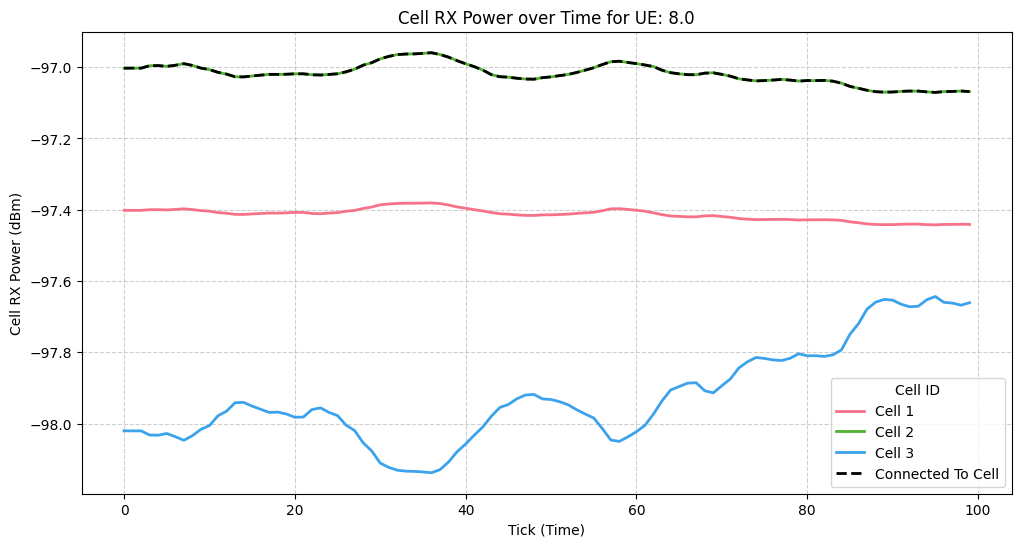

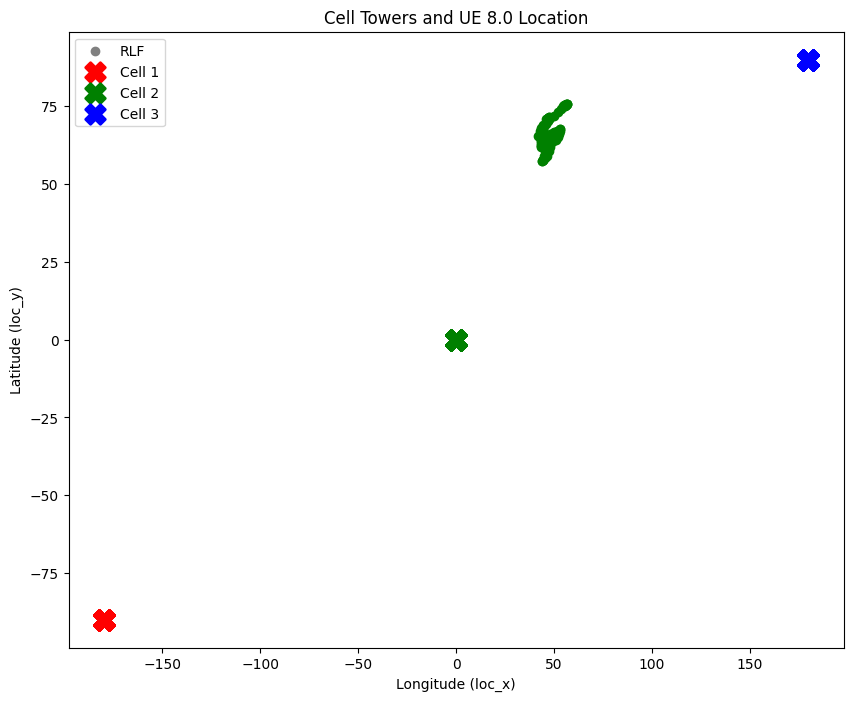

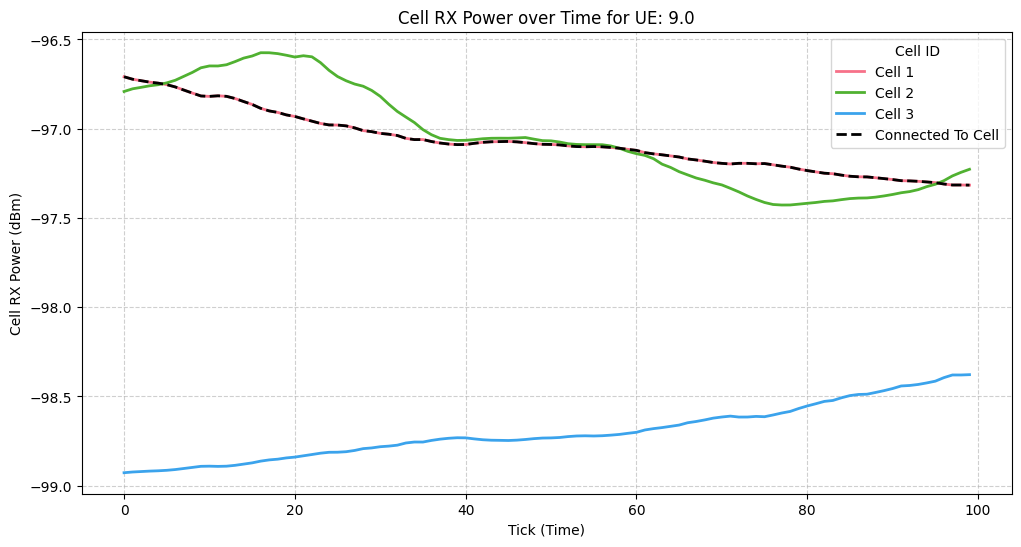

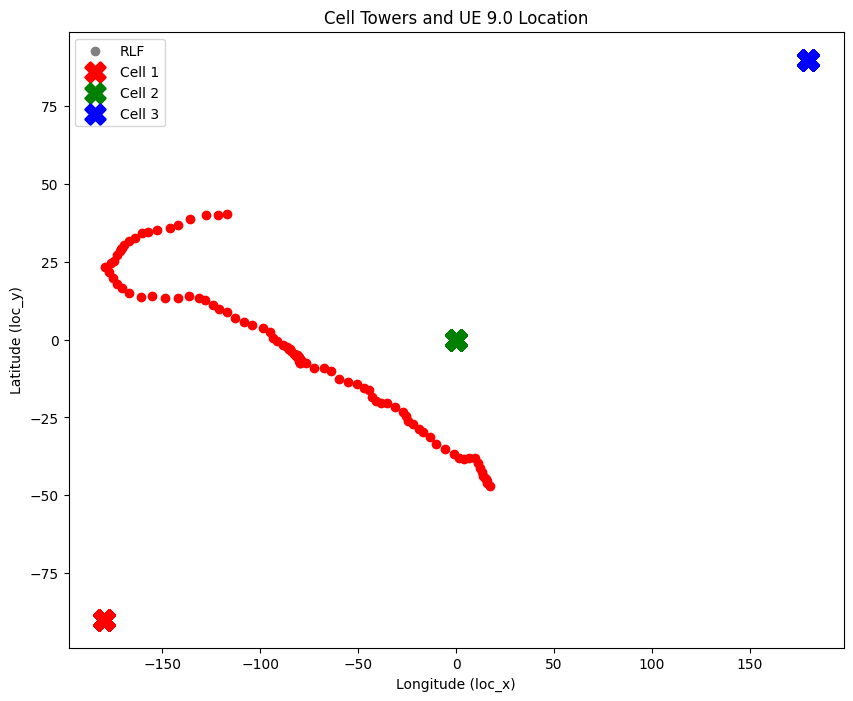

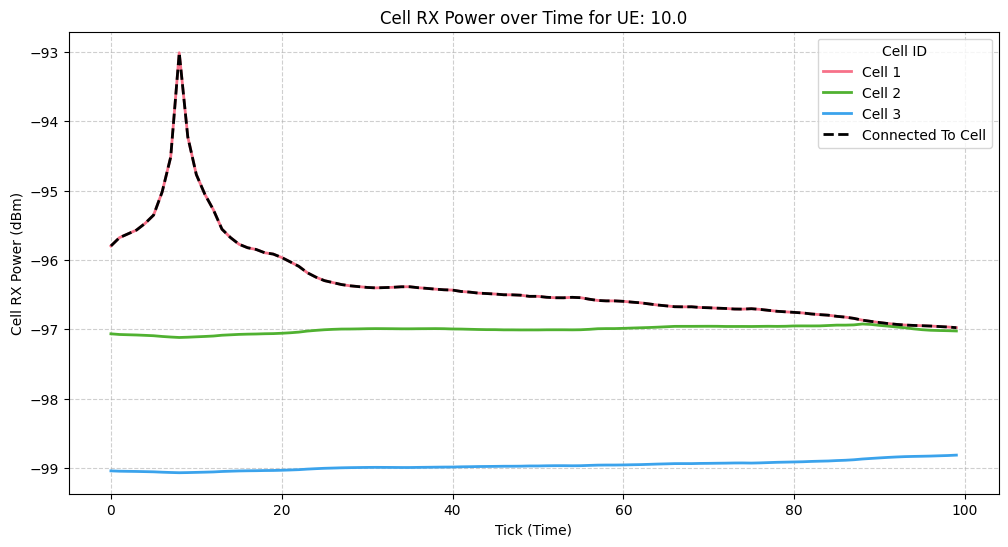

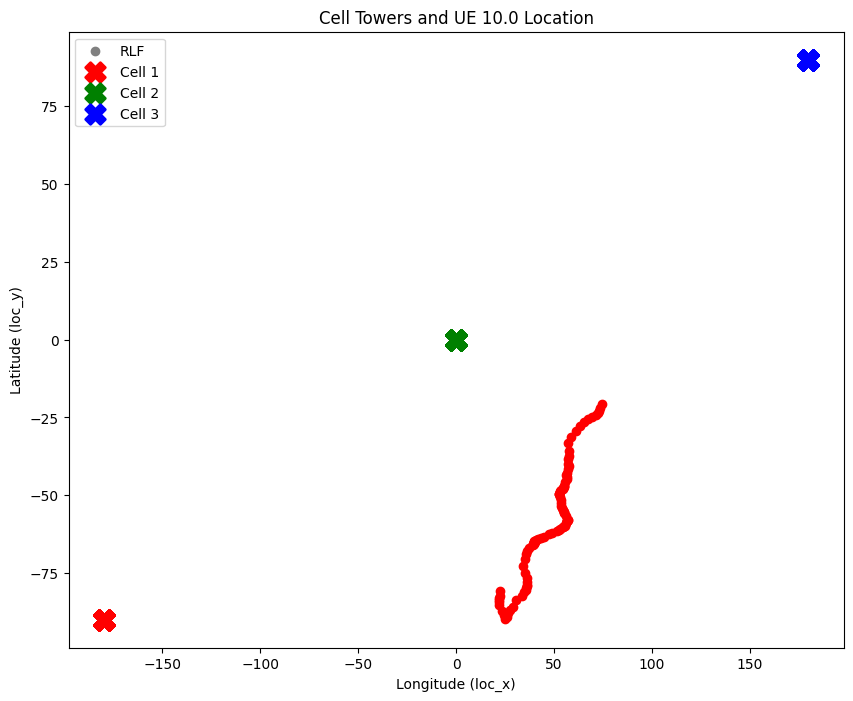

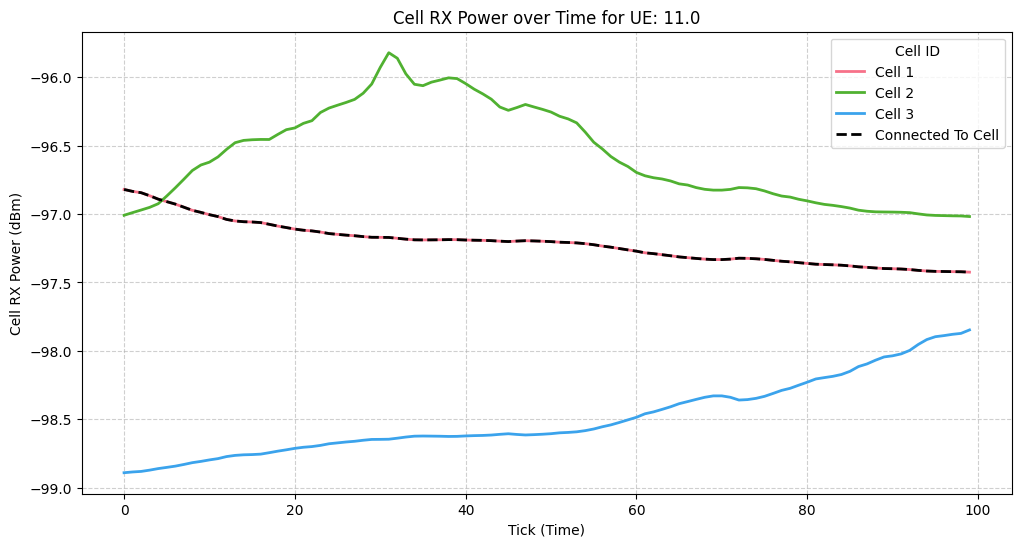

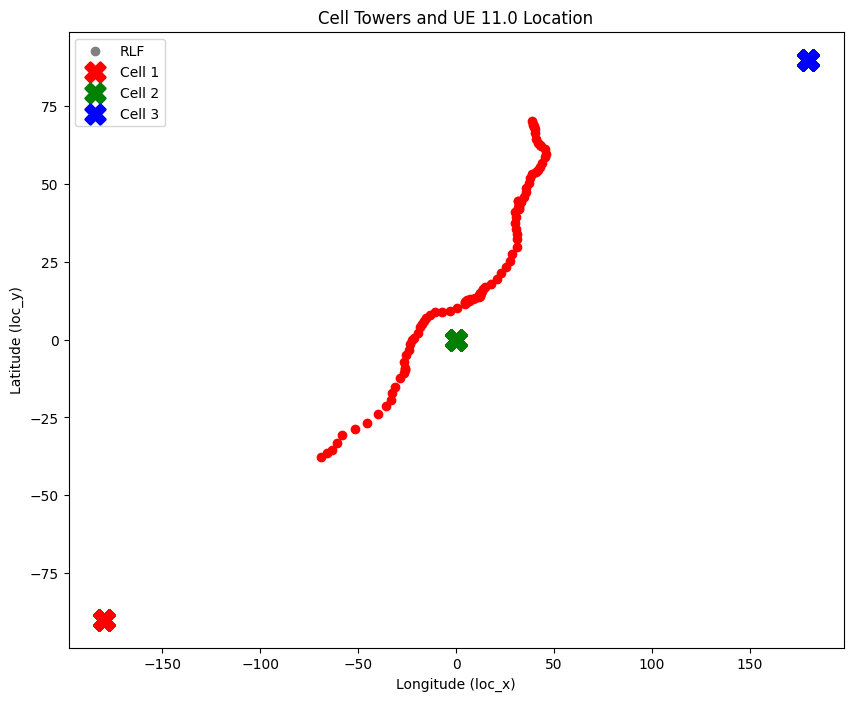

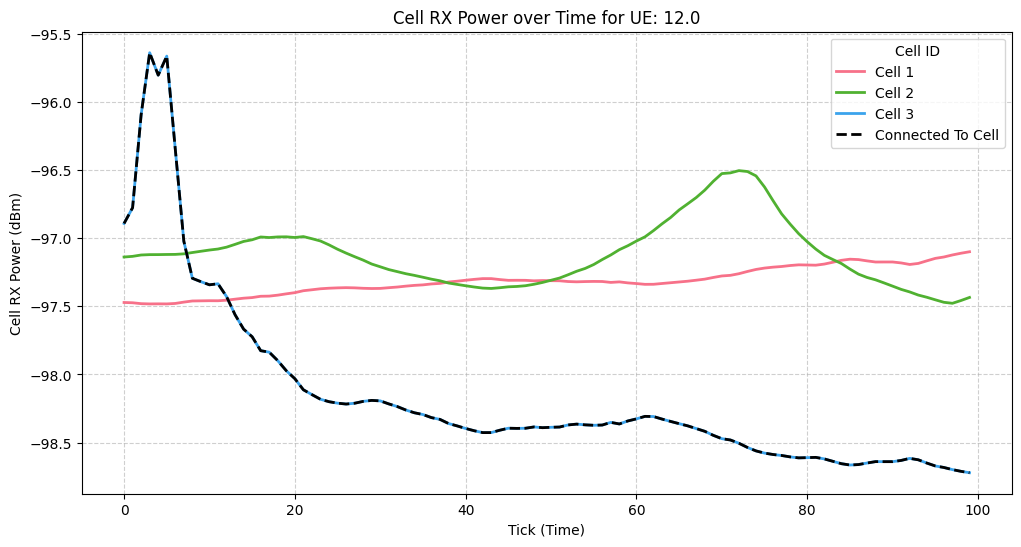

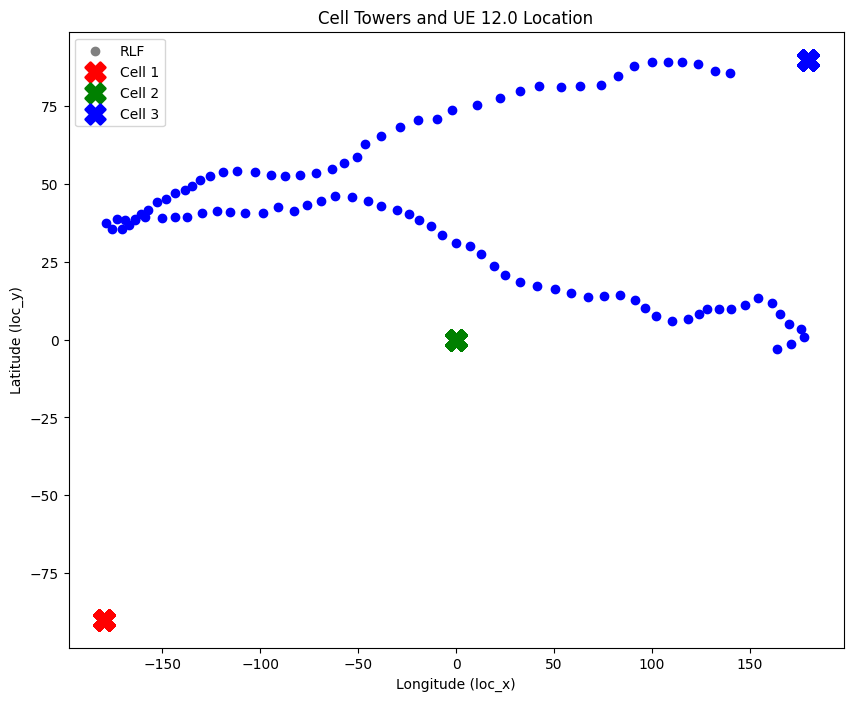

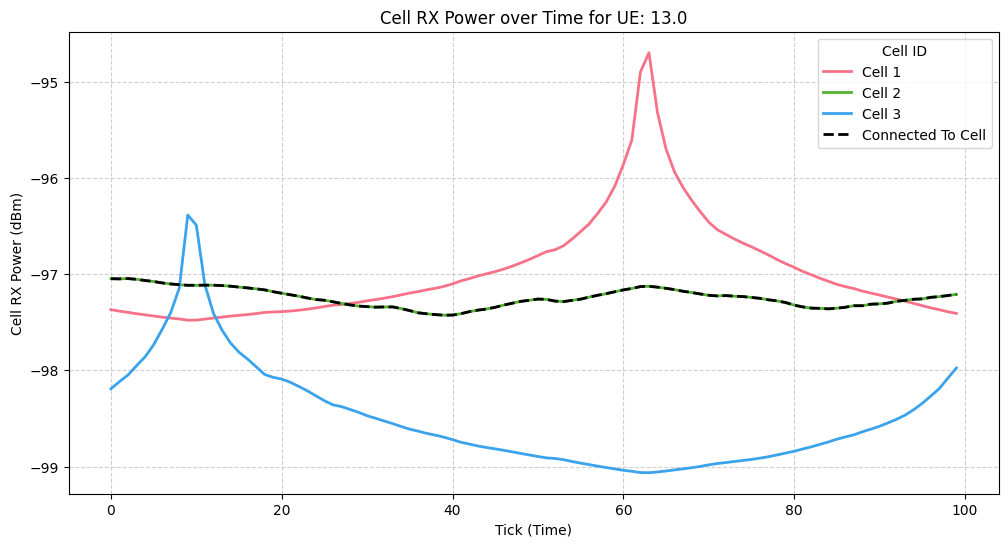

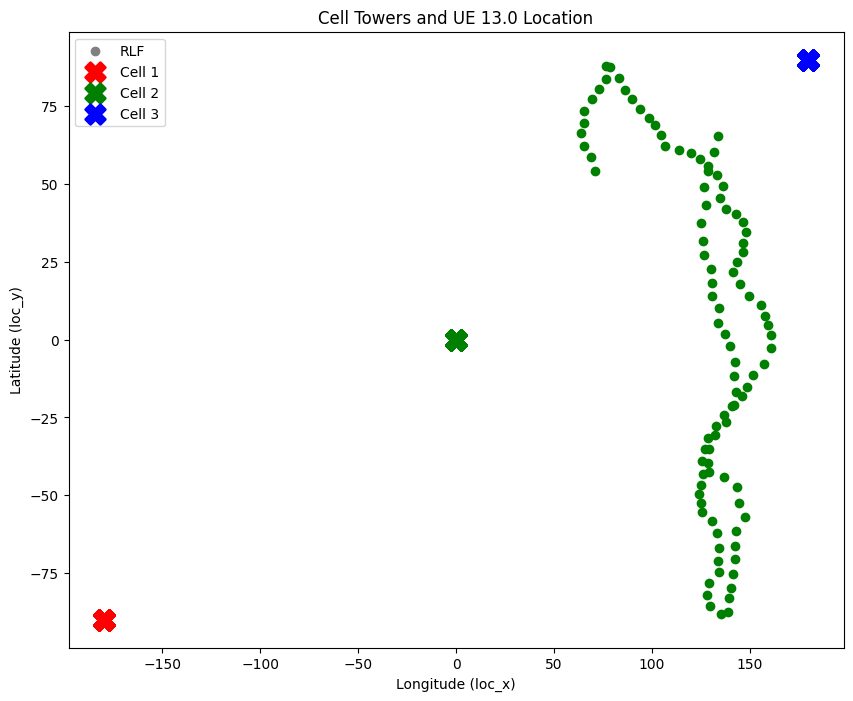

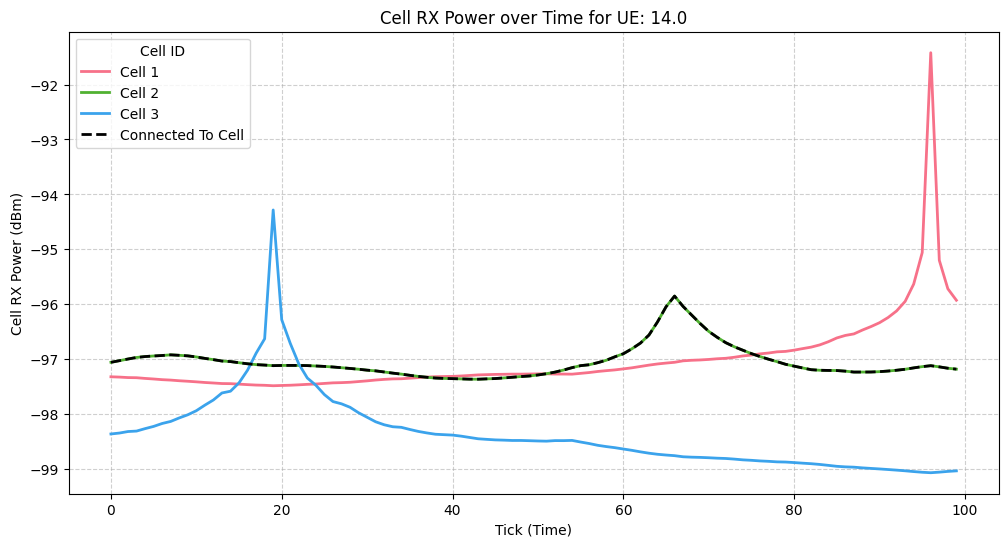

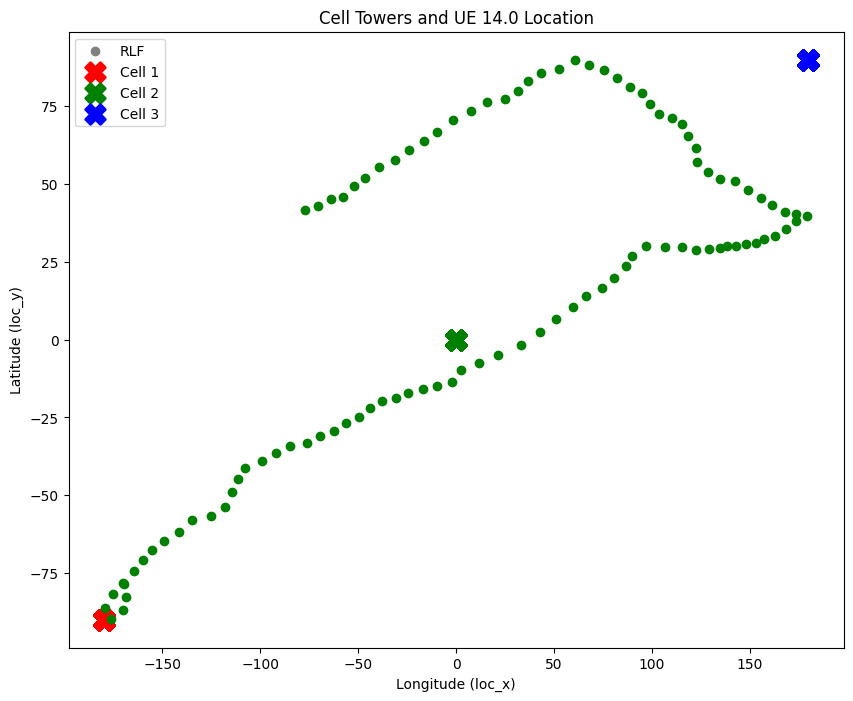

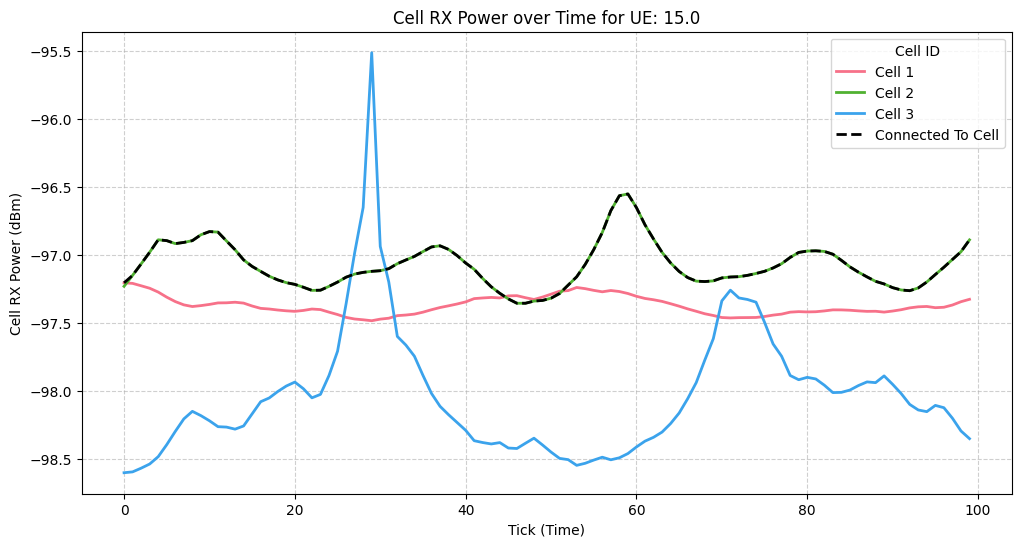

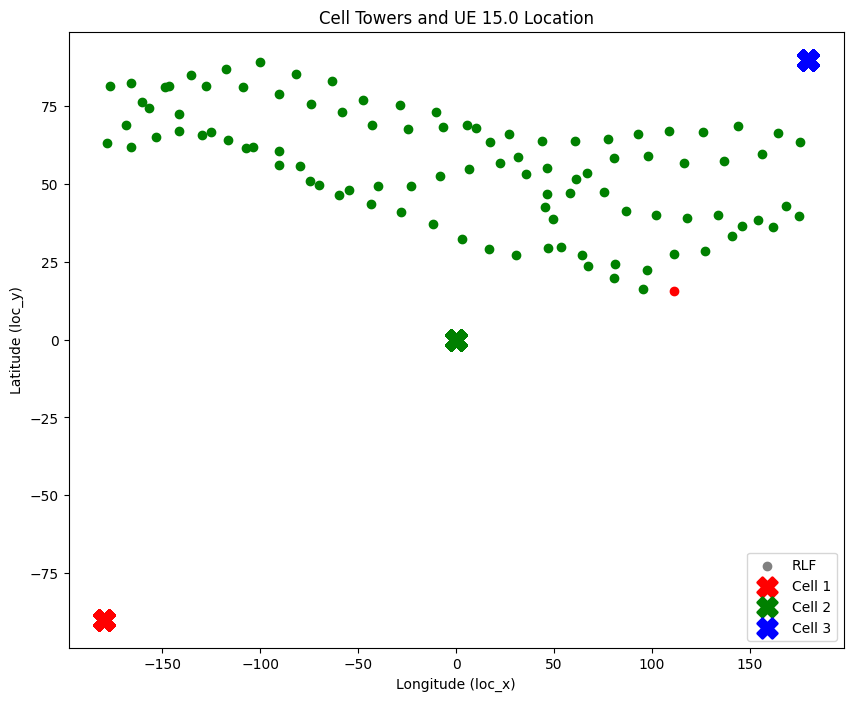

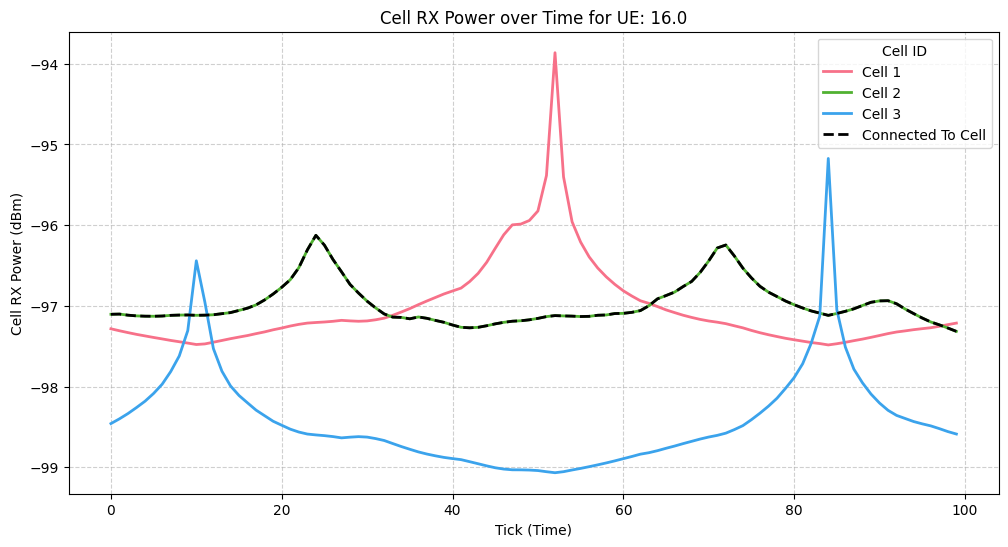

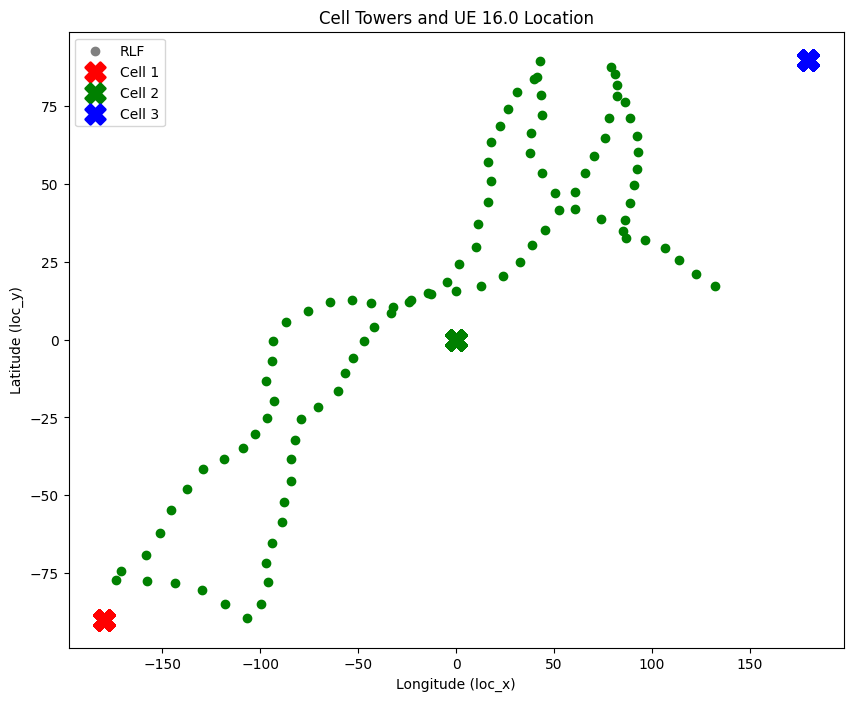

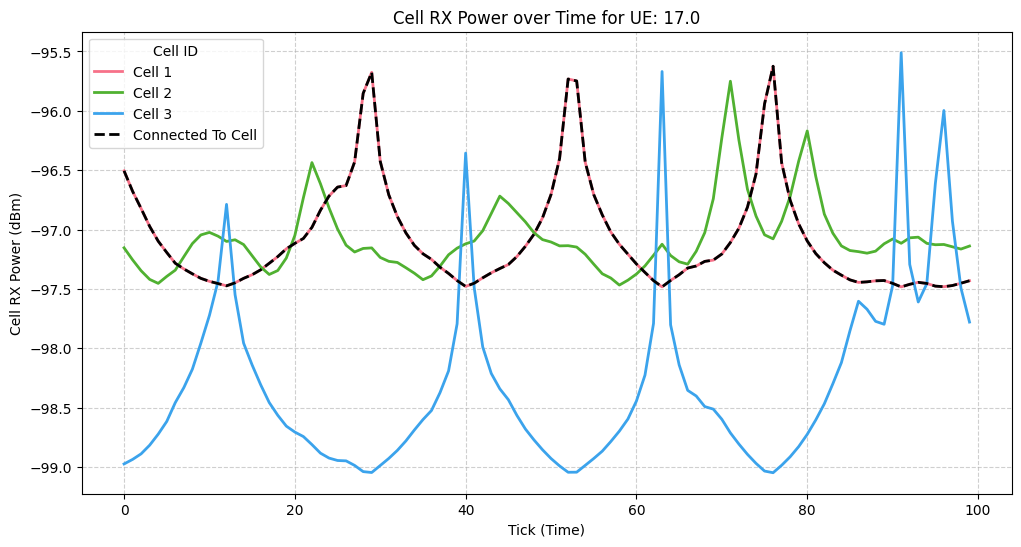

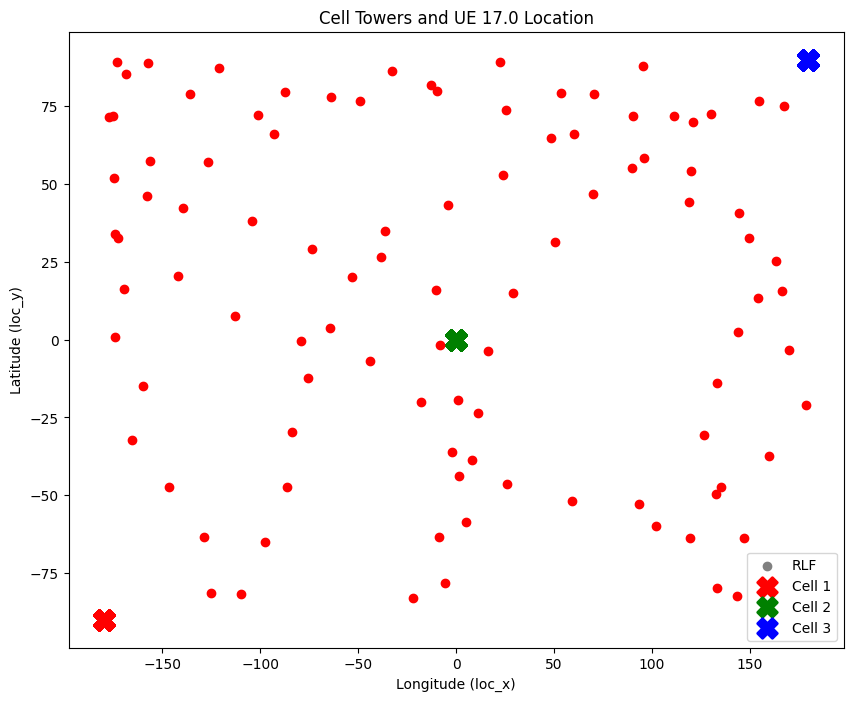

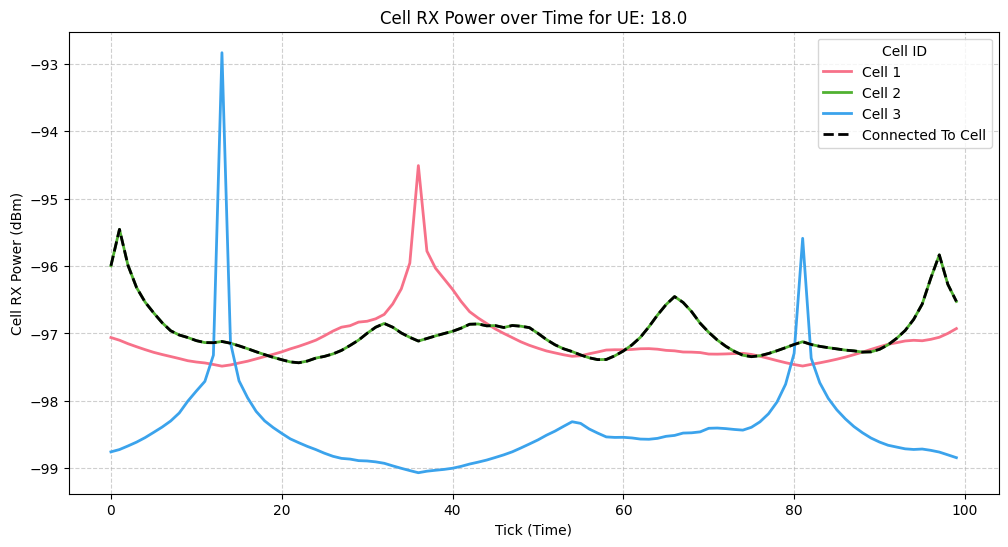

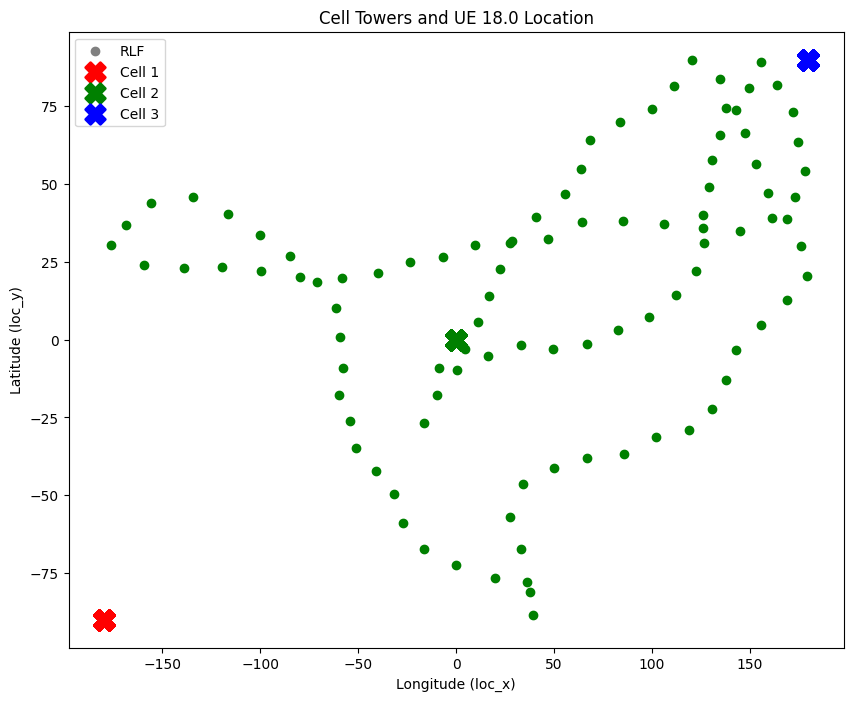

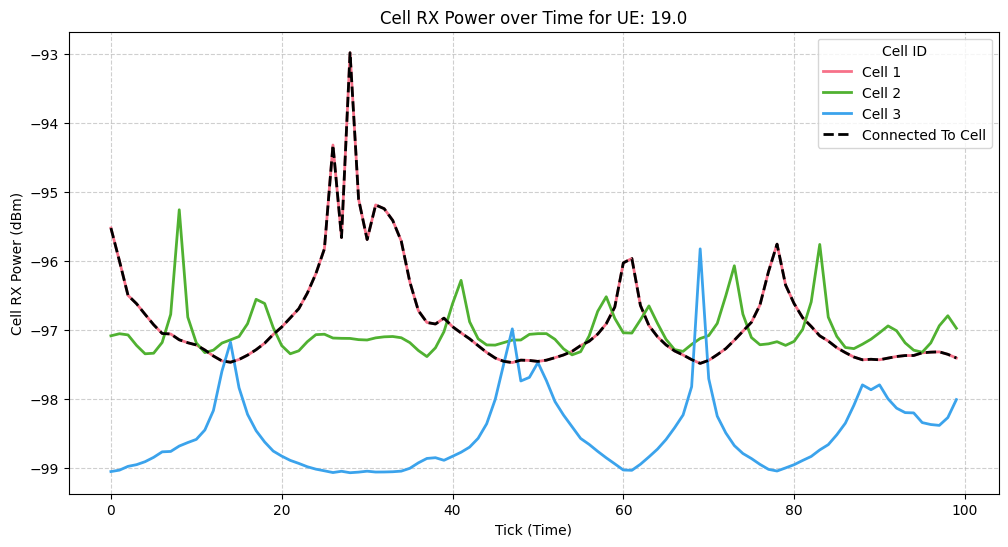

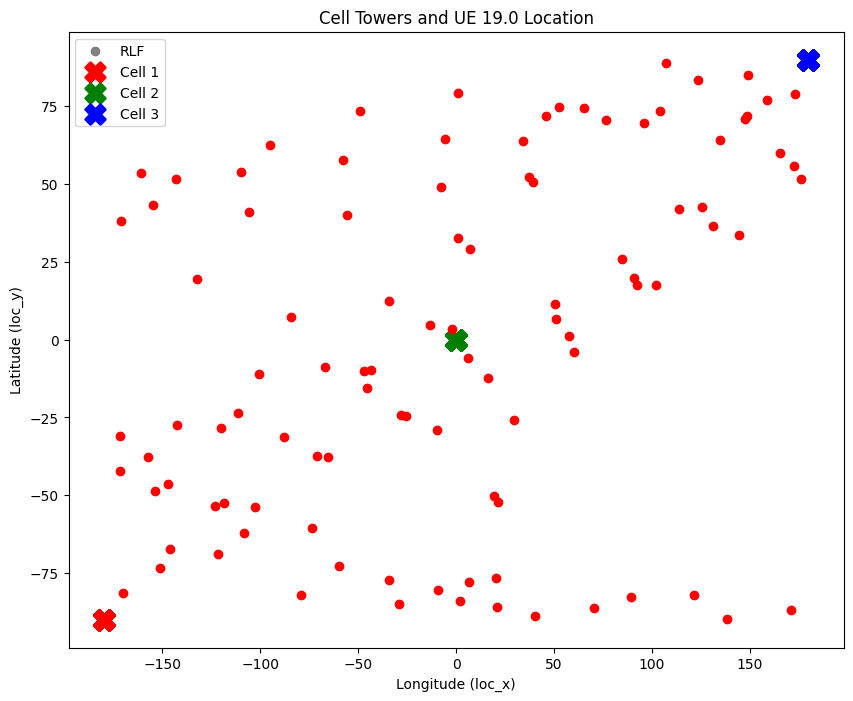

In [26]:
ue_ids = attached_df['ue_id'].unique()
for i in ue_ids:
    plots.plot_ue_rxpower_over_time(attached_df, data, i)
    plots.individual_scatter_plot(attached_df, data, i)